In [1]:
import os
import tifffile
import stackview
import numpy as np
import napari
import matplotlib.pyplot as plt
import pandas as pd
from skimage import exposure
import math
from matplotlib.widgets import Slider
from ipywidgets import interact, IntSlider
from IPython.display import display, clear_output

In [2]:
base = "CME"

if base == "CME":
    sec = "Dino"
if base == "Dino":
    sec = "CME"

In [3]:
def plot(ax, time, boxsize, Comparison, CME_detections, Dino_detections):
    ID1 = Comparison[Comparison["t"] == time].sort_values([f"ID ({base})", "t"], ascending = [True, True])

    Dino_time = Dino_detections[Dino_detections["timepoint"]==time]
    
    CME_time = CME_detections[CME_detections[0]==time]

    selected_folder = folders[time-1]
    
    volume_path = os.path.join(root_dir, selected_folder, "volume.tif")
    volume = tifffile.imread(volume_path)
    
    sec_ID = ID1[f"ID ({sec})"].values[0]
    color = ID1["Color"].values[0]

    selected_folder = folders[time - 1]
    volume_path = os.path.join(root_dir, selected_folder, "volume.tif")
    volume = tifffile.imread(volume_path)

    z_CME = ID1[f"z (CME)"].values[0]
    x_CME = ID1[f"x (CME)"].values[0]
    y_CME = ID1[f"y (CME)"].values[0]
    z_Dino = ID1[f"z (Dino)"].values[0]
    x_Dino = ID1[f"x (Dino)"].values[0]
    y_Dino = ID1[f"y (Dino)"].values[0]
    FI_base = round(ID1[f"FI ({base})"].values[0], 2)
    Distance = round(ID1["Distance"].values[0], 2)

    if base == "CME":
        x_base, y_base, z_base = x_CME, y_CME, z_CME
        x_sec, y_sec, z_sec = x_Dino, y_Dino, z_Dino
        base_color = "darkred"
    if base == "Dino":
        x_base, y_base, z_base = x_Dino, y_Dino, z_Dino
        x_sec, y_sec, z_sec = x_CME, y_CME, z_CME
        base_color = "darkblue"
        
    H, W = volume.shape[1:3]
    y1 = max(0, int(round(y_base - boxsize / 2)))
    y2 = min(H, y1 + boxsize)
    x1 = max(0, int(round(x_base - boxsize / 2)))
    x2 = min(W, x1 + boxsize)

    frame = volume[int(round(z_base)), y1:y2, x1:x2]
    patch_ymin = y1
    patch_xmin = x1
    patch_ymax = patch_ymin + frame.shape[0]
    patch_xmax = patch_xmin + frame.shape[1]

    z_tol=2

    mask_z = (CME_time[4] >= z_CME - z_tol) & (CME_time[4] <= z_CME + z_tol)
    close_points = CME_time[mask_z]
    patch_mask = (close_points[2] >= patch_xmin) & (close_points[2] < patch_xmax) & \
                 (close_points[3] >= patch_ymin) & (close_points[3] < patch_ymax)
    close_points = close_points[patch_mask]
    label_added = False
    for idx, row in close_points.iterrows():
        if row[2] != x_CME:
            label = f"{base} Det" if not label_added else ""
            ax.scatter(row[2], row[3], color="blue", label=label)
            label_added = True
    
    mask_z = (Dino_time["z"] >= z_CME - z_tol) & (Dino_time["z"] <= z_CME + z_tol)
    close_points = Dino_time[mask_z]
    patch_mask = (close_points["x"] >= patch_xmin) & (close_points["x"] < patch_xmax) & \
                 (close_points["y"] >= patch_ymin) & (close_points["y"] < patch_ymax)
    close_points = close_points[patch_mask]
    label_added = False
    for idx, row in close_points.iterrows():
        if row["x"] != x_Dino:
            ax.scatter(row["x"], row["y"], color="red", label=f"{sec} Det" if not label_added else "")
            label_added = True

    ax.imshow(
        frame, cmap="gray", vmin=0, vmax=0.3,
        extent=[
            patch_xmin, patch_xmax,
            patch_ymax, patch_ymin
        ]
    )
    
    ax.scatter(x_base, y_base, color=base_color, label=f"{base} Base")
    if (patch_xmin <= x_sec < patch_xmax) and (patch_ymin <= y_sec < patch_ymax):
        ax.scatter(x_sec, y_sec, color=color, label=f"{sec} Close")
            
    ax.legend(fontsize=8)
    ax.text(
        patch_xmin + 0.5, patch_ymin + 5,
        f"t = {time}\n{sec} ID {int(sec_ID)}\nDistance = {Distance}",
        fontsize=8,
        color="black",
        bbox=dict(boxstyle="round", fc="white", alpha=0.7)
    )
    for spine in ax.spines.values():
        spine.set_color(color)
        spine.set_linewidth(2)
    ax.set_xticks([])
    ax.set_yticks([])

In [4]:
def FI(ID, Comparison, Coverage):
    ID_comp = Comparison[Comparison[f"ID ({base})"] == ID]
    ID_cov = Coverage[Coverage[f"ID ({base})"] == ID]
    comp = ID_comp.to_numpy()
    cov = ID_cov.to_numpy()
    data = cov[0][4]
    y_data = np.array([row.split(',') for row in data.split(';')], float)
    FI_y = np.zeros((len(y_data)),dtype=object)
    t_y = np.zeros((len(y_data)),dtype=object)
    for i, rows in enumerate(y_data[:-1]):
        FI_y[i] = comp[int(y_data[i][1]-1):int(y_data[i+1][1]-1),12]
        t_y[i] = comp[int(y_data[i][1]-1):int(y_data[i+1][1]-1),8]
    FI_y[-1] = comp[int(y_data[-1][1]-1):,12]
    t_y[-1] = comp[int(y_data[-1][1]-1):,8]
    ID_y = y_data[:,0]
    FI_x = comp[:,11]
    t_full = comp[:,8]

    return t_full, FI_x, t_y, ID_y, FI_y

def FI_plot(ID_array, data):
    ids = np.atleast_1d(ID_array)
    n = len(ids)
    if n in [3, 4]:
        rows, cols = 2, 2
    else:
        cols = min(n, 3)
        rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
    axes = np.array(axes).reshape(-1)
    for idx, ID in enumerate(ids):
        t_full, FI_x, t_y, ID_y, FI_y = data
        mD, mC = max(map(max, FI_y)), np.max(FI_x)
        ax = axes[idx]
        uniq = np.unique(ID_y)
        colors = [plt.cm.gist_rainbow(i/len(uniq)) for i in range(len(uniq)+1)]
        
        t_full = np.array(t_full, dtype=float)
        FI_x = np.array(FI_x, dtype=float)
        
        idx = np.where(np.diff(t_full) > 1)[0] + 1
        segments = np.split(np.arange(len(t_full)), idx)
        
        for i, s in enumerate(segments):
            if len(s) == 1:
                xx = np.array([t_full[s[0]] - 0.1, t_full[s[0]] + 0.1])
                yy = np.array([FI_x[s[0]]/mC, FI_x[s[0]]/mC])
                ax.plot(xx, yy, color=colors[0], label=f"{base}: {ID}" if i == 0 else None)
            elif len(s) > 1:
                ax.plot(t_full[s], FI_x[s]/mC, color=colors[0], label=f"{base}: {ID}" if i == 0 else None)
        
        plotted = set()
        for i, j in enumerate(ID_y):
            k = np.where(uniq==j)[0][0]
            x, y = np.array(t_y[i], dtype=float), np.array(FI_y[i]/mD, dtype=float)
            label = f"{sec}: {j}" if j not in plotted else None
        
            if len(x) == 1:
                xx = np.array([x[0]-0.1, x[0]+0.1])
                yy = np.array([y[0], y[0]])
                ax.plot(xx, yy, color=colors[k+1], label=label)
            else:
                idx = np.where(np.diff(x) > 1)[0] + 1
                segs = np.split(np.arange(len(x)), idx)
                for si, s in enumerate(segs):
                    if len(s) == 1:
                        xx = np.array([x[s[0]]-0.1, x[s[0]]+0.1])
                        yy = np.array([y[s[0]], y[s[0]]])
                        ax.plot(xx, yy, color=colors[k+1], label=label if si == 0 else None)
                    else:
                        ax.plot(x[s], y[s], color=colors[k+1], label=label if si == 0 else None)
            plotted.add(j)
        ax.set(xlim=(0,100), xlabel="Time", ylabel="FI", title=f"ID ({base}): {ID}")
        ax.legend(labelspacing=0.2)
    for ax in axes[n:]: ax.axis("off")
    plt.tight_layout()
    plt.show()

Generated 0.0 %
Generated 20.0 %
Generated 50.0 %
Generated 70.0 %
Generated 90.0 %


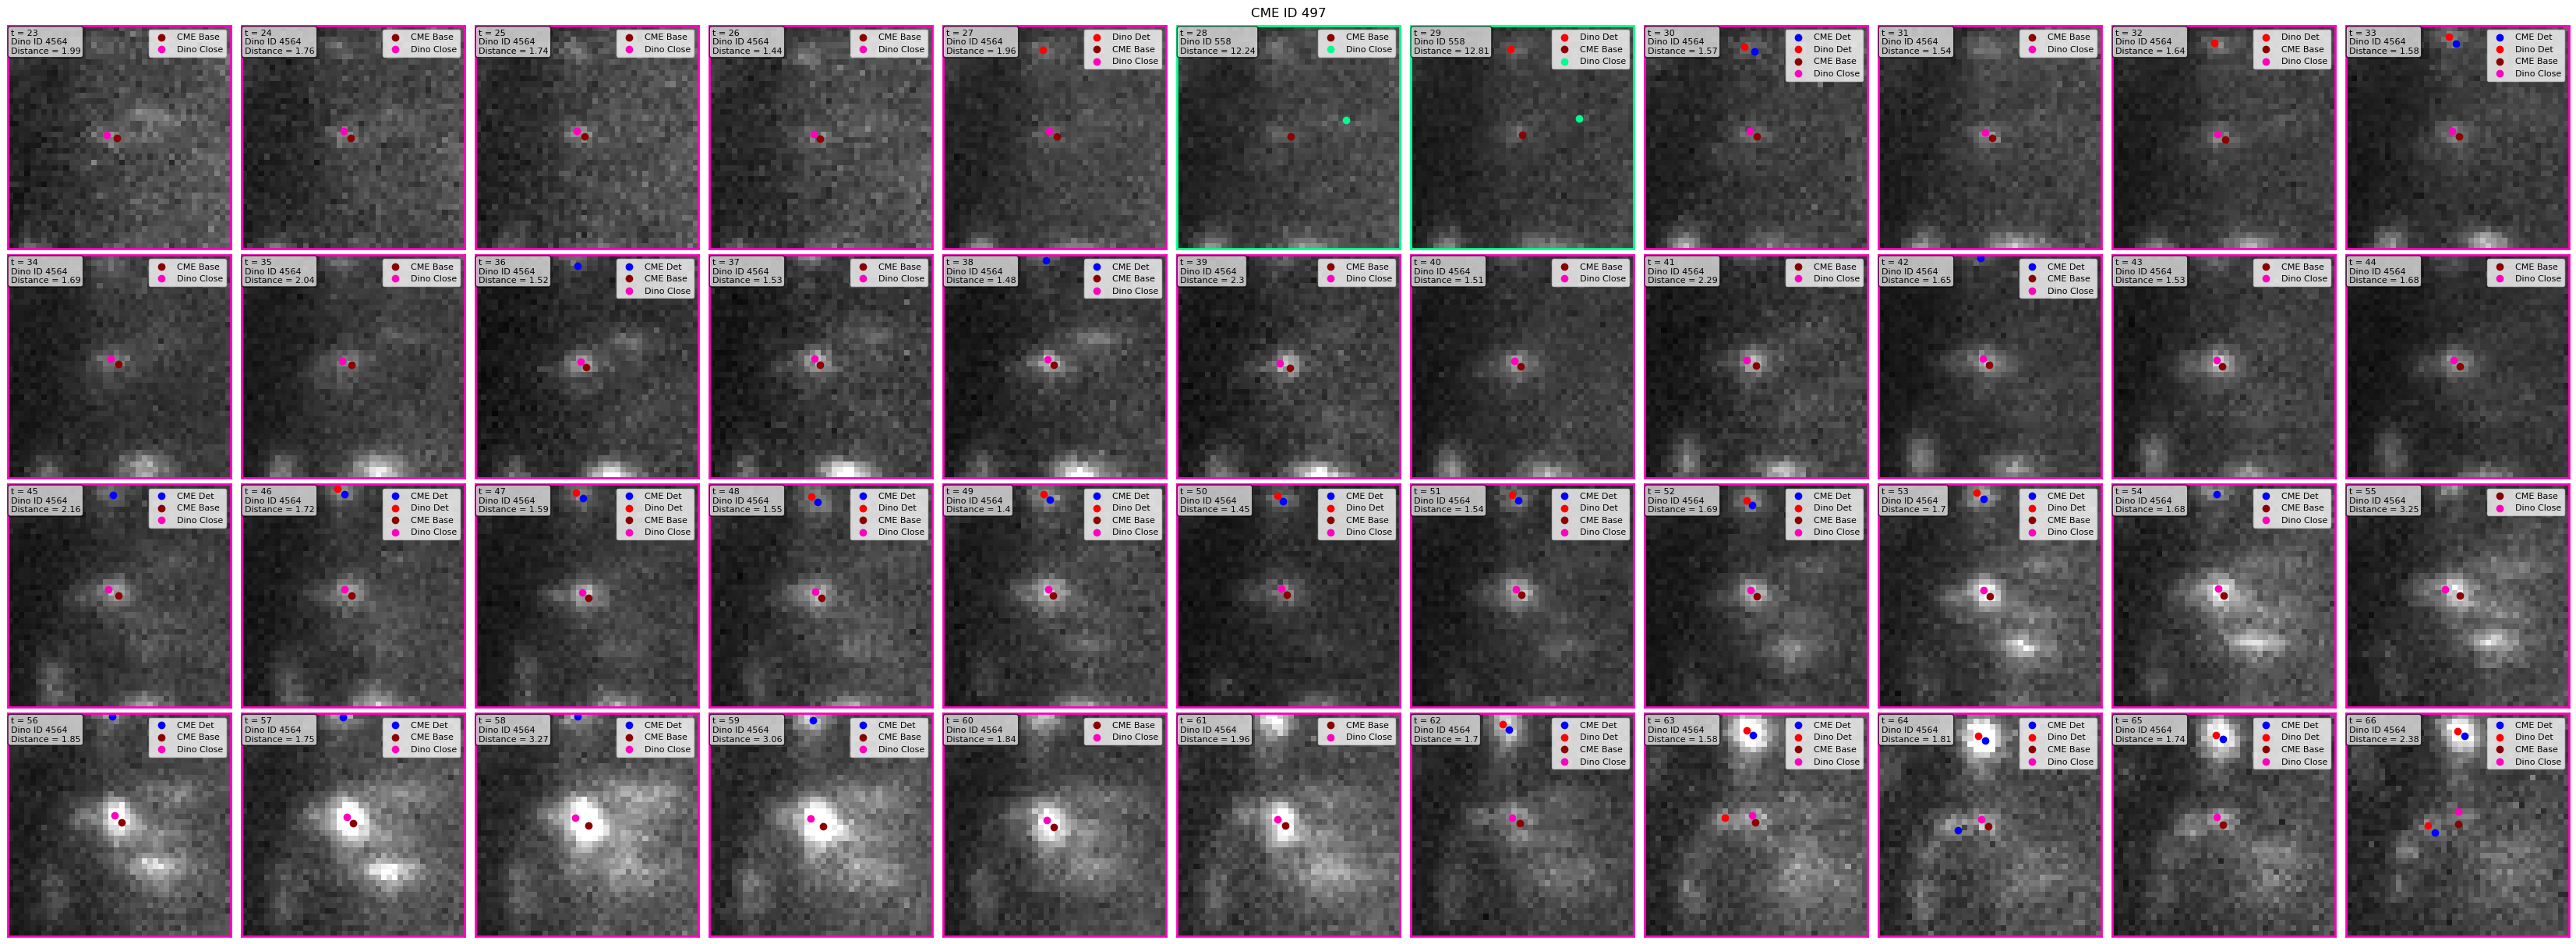

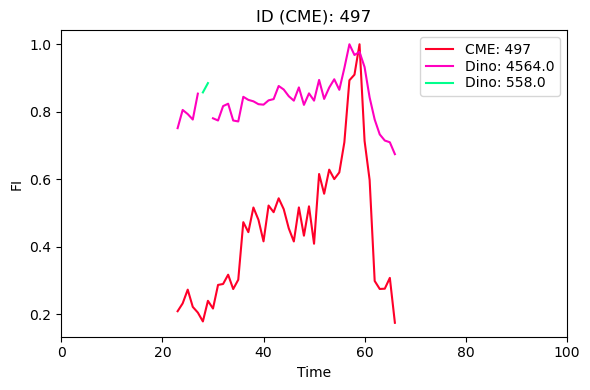

Generated 0.0 %
Generated 20.0 %
Generated 50.0 %
Generated 70.0 %
Generated 90.0 %


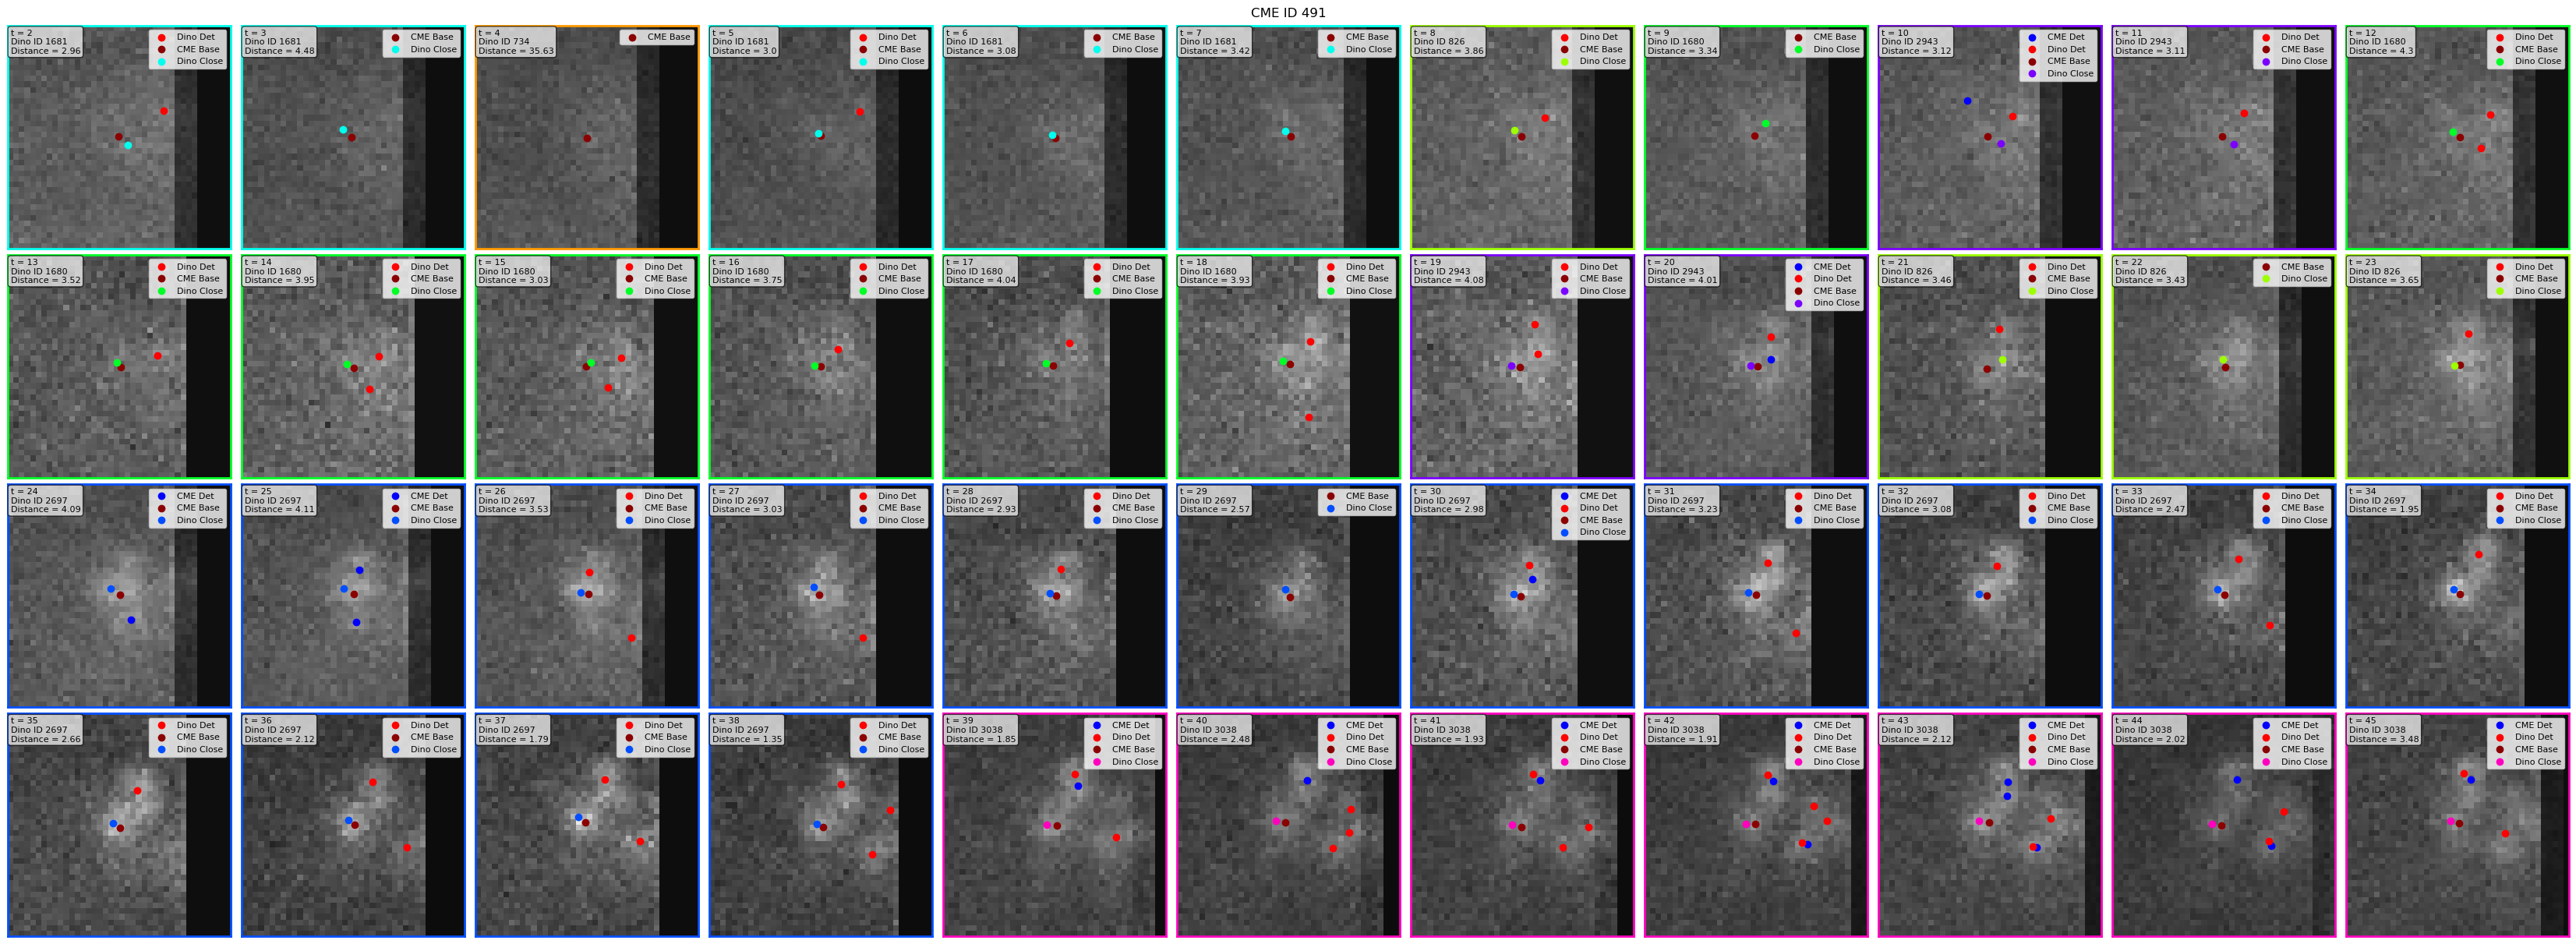

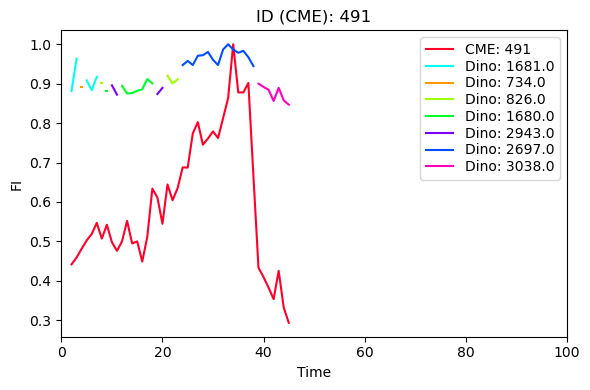

In [5]:
Comp = pd.read_csv(f"{base} Base Output/Comparison.csv")
Dino_det = pd.read_csv("Input Data/detections_Dino.csv")
Dino_det["timepoint"] = Dino_det["timepoint"] + 1
CME_det = pd.read_csv("Input Data/detections_CME.csv", header = None)
Cov = pd.read_csv(f"{base} Base Output/ID_Coverage.csv")

root_dir = "/nfs/scratch2/shared_image_recog_ml/ap2_unnorm"
folders = [
        f for f in os.listdir(root_dir)
        if os.path.isdir(os.path.join(root_dir, f))
        and not f.startswith(".")
    ]
folders.sort()

IDs = [497, 491]
#IDs = [491,497,499,519,524,528,541,554,556,557,560,573,574,597,598,623,661,670,674,683,685,711,716,718,722,726,739,789,805,838,845,864,874,884,889,893,932,939,948,1006,1065,1084,1122,1125,1130,1150,1200,1212,1264,1281,1284,1291,1322,1330,1336,1282]
boxsize = 40

for ID in IDs:

    choice = Comp[Comp[f"ID ({base})"] == ID]
    time = choice["t"].values
    
    n_plots = len(time)
    n_cols = 11
    n_rows = math.ceil(n_plots / n_cols)
    n_timepoints = len(time)
    
    uniq = np.unique(choice[f"ID ({sec})"])
    colors = [plt.cm.gist_rainbow(i/len(uniq)) for i in range(len(uniq)+1)][1:]
    
    uniq_colors = pd.DataFrame({f"ID ({sec})": uniq, "Color": colors})
    
    ID_Comp = pd.merge(choice, uniq_colors, on = f"ID ({sec})")
    
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows), constrained_layout=True)
    fig.suptitle(f"{base} ID {int(ID)}")
    
    axs = axs.flatten()
    
    for i, t_now in enumerate(time):
        if i%10 == 0:
            print(f"Generated {round((i+1)/len(time),1)*100} %")
        plot(axs[i], int(t_now), boxsize, ID_Comp, CME_det, Dino_det)
    
    for ax in axs[n_plots:]:
        ax.axis('off')

    FI_data = FI(ID, Comp, Cov)
    FI_plot(ID, FI_data)
    plt.show()



In [6]:
c = pd.read_csv(f"Input Data/ap2_Dino.csv")

display(Comp[Comp["ID (CME)"]==491])
c[c["ID"]==1681]

,ID (CME),ID (Dino),x (CME),y (CME),z (CME),x (Dino),y (Dino),z (Dino),t,t_start (CME),t_start (Dino),FI (CME),FI (Dino),Track Length (CME),Track Length (Dino),Distance,Multi ID (Dino),Multi Distance (Dino)
23406,491.0,1681.0,682.89,177.97,104.765,684.57970,179.51650,102.894600,2.0,2.0,2.0,142.580,317.2,44.0,16.0,2.957219,1681,2.96
23407,491.0,1681.0,683.78,179.05,104.997,682.24896,177.72447,100.999830,3.0,2.0,2.0,148.190,346.8,44.0,16.0,4.480902,NaN,NaN
23408,491.0,734.0,683.96,179.13,105.370,665.01624,206.21584,92.072624,4.0,2.0,1.0,155.410,321.0,44.0,33.0,35.627643,NaN,NaN
23409,491.0,1681.0,682.99,178.82,104.820,682.62897,178.41020,101.869415,5.0,2.0,2.0,162.210,327.0,44.0,16.0,3.000705,1681,3.00
23410,491.0,1681.0,684.15,178.25,105.332,683.56210,177.69310,102.359985,6.0,2.0,2.0,167.570,318.0,44.0,16.0,3.080363,1681,3.08
23411,491.0,1681.0,683.38,177.95,104.859,682.39910,177.00360,101.726425,7.0,2.0,2.0,176.630,330.2,44.0,16.0,3.416265,1681,3.42
23412,491.0,826.0,683.91,177.86,104.677,682.60740,176.85117,101.191140,8.0,2.0,1.0,163.750,324.8,44.0,20.0,3.855610,NaN,NaN
23413,491.0,1680.0,683.67,177.73,104.733,685.74560,175.49648,103.361000,9.0,2.0,2.0,175.100,317.5,44.0,47.0,3.343518,"2697,1680","3.38,3.34"
23414,491.0,2943.0,683.54,177.95,104.647,685.91600,179.14218,103.009590,10.0,2.0,10.0,160.780,322.5,44.0,12.0,3.122144,2943,3.12
23415,491.0,2943.0,683.67,177.86,104.730,685.86090,179.31342,103.073890,11.0,2.0,10.0,153.740,314.0,44.0,12.0,3.107277,2943,3.11


,ID,t_starting,t,x,y,z,intensity,max_intensity,track_length
119428,1681,1,1,684.57970,179.51650,102.894600,317.2,350.5,16
119429,1681,1,2,682.24896,177.72447,100.999830,346.8,331.8,16
119430,1681,1,4,682.62897,178.41020,101.869415,327.0,364.5,16
119431,1681,1,5,683.56210,177.69310,102.359985,318.0,361.0,16
119432,1681,1,6,682.39910,177.00360,101.726425,330.2,377.2,16
119433,1681,1,7,678.26480,170.53479,98.815370,296.8,300.8,16
119434,1681,1,10,671.99760,171.52340,95.999664,288.5,282.5,16
119435,1681,1,11,671.99740,171.57729,95.999626,285.5,294.0,16
119436,1681,1,14,671.99744,171.50568,95.999630,278.5,268.8,16
119437,1681,1,55,643.99630,165.99904,96.999450,303.8,287.0,16
